# NB04 — Batch-Controlled Within-Study Analysis

NB03 shows the cross-study environment effect does **not** generalise (out-of-study R²<0): environment is
confounded with study/batch across NMDC. The cleanest available control is to look **inside a single large study**,
where sampling protocol, wet-lab handling, and sequencing batch are (largely) constant, and ask whether euk fraction
still varies with the metadata that genuinely varies *within* that study (`env_local_scale`, `ecosystem_subtype`,
geography). If it does, the environment/eukaryote link is not purely batch. We use the dominant soil study.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold
DATA=Path('../data'); FIG=Path('../figures')
plt.rcParams.update({'figure.dpi':110,'savefig.bbox':'tight','axes.grid':True,'grid.alpha':.3})
df=pd.read_csv(DATA/'analysis_clean.csv')
S=df['study_id'].value_counts().idxmax()
d=df[df['study_id']==S].copy()
print(f'dominant study {S}: {len(d)} runs')
print('matrix within study:', d['matrix'].unique())
print('euk detection within study:', round((d['gott_euk_frac']>0).mean(),3),
      '| median euk:', round(d['gott_euk_frac'].median(),4))

dominant study nmdc:sty-11-34xj1150: 1186 runs
matrix within study: <ArrowStringArray>
['Terrestrial', 'Unknown']
Length: 2, dtype: str
euk detection within study: 0.514 | median euk: 0.0032


## Within-study metadata variation

In [2]:
for col in ['env_local','ecosystem_subtype','geo_loc','samp_collec_device']:
    print(f'{col:20s} {d[col].nunique()} distinct')
print('\nenv_local_scale distribution:')
print(d['env_local'].value_counts().head(12).to_string())

env_local            11 distinct
ecosystem_subtype    7 distinct
geo_loc              47 distinct
samp_collec_device   9 distinct

env_local_scale distribution:
env_local
area of evergreen forest                                   321
area of deciduous forest                                   266
area of gramanoid or herbaceous vegetation                 182
area of scrub                                              148
area of mixed forest                                        76
area of woody wetland                                       58
area of cropland                                            34
area of sedge- and forb-dominated herbaceous vegetation     33
area of pastureland or hayfields                            30
area of dwarf scrub                                         23
area of emergent herbaceous wetland                         15


## H1a within-study — euk fraction by within-study environment (batch held ~constant)

In [3]:
def kruskal_by(col, minn=15):
    g=d.groupby(col).filter(lambda x:len(x)>=minn)
    levels=[v for v,c in g[col].value_counts().items()]
    if len(levels)<2: return None
    H,p=stats.kruskal(*[g.loc[g[col]==l,'gott_euk_frac'] for l in levels])
    return len(levels),len(g),H,p
for col in ['env_local','ecosystem_subtype']:
    r=kruskal_by(col)
    if r: print(f'{col:20s} Kruskal over {r[0]} levels (n={r[1]}): H={r[2]:.1f}, p={r[3]:.2e}')
    else: print(f'{col:20s} insufficient levels')
# summary table for env_local
tab=d.groupby('env_local')['gott_euk_frac'].agg(n='size',median='median',
     detect=lambda s:(s>0).mean(),gt20=lambda s:(s>0.2).mean()).round(4)
tab=tab[tab['n']>=15].sort_values('median',ascending=False); display(tab)
tab.to_csv(DATA/'nb04_within_study_env_local.csv')

env_local            Kruskal over 11 levels (n=1186): H=119.1, p=7.61e-21
ecosystem_subtype    Kruskal over 5 levels (n=1161): H=9.5, p=5.05e-02


,n,median,detect,gt20
env_local,,,,
area of sedge- and forb-dominated herbaceous vegetation,33,0.2311,0.9697,0.6061
area of emergent herbaceous wetland,15,0.1350,0.8000,0.4667
area of dwarf scrub,23,0.1317,0.9130,0.3913
area of evergreen forest,321,0.0228,0.6106,0.1713
area of mixed forest,76,0.0025,0.5000,0.0921
area of deciduous forest,266,0.0000,0.4737,0.0977
area of cropland,34,0.0000,0.2941,0.0294
area of gramanoid or herbaceous vegetation,182,0.0000,0.4396,0.1319
area of pastureland or hayfields,30,0.0000,0.3333,0.1000


## Geographic structure within study (spatial ≈ environment, batch-controlled)

In [4]:
geo=d.groupby('geo_loc')['gott_euk_frac'].agg(n='size',median='median').query('n>=15').sort_values('median',ascending=False)
print(f'{len(geo)} geo locations with >=15 runs; euk median range {geo["median"].min():.3f}-{geo["median"].max():.3f}')
display(geo.head(12))
if len(geo)>=2:
    H,p=stats.kruskal(*[d.loc[d.geo_loc==g,'gott_euk_frac'] for g in geo.index])
    print(f'Kruskal euk across {len(geo)} geo locations: H={H:.1f}, p={p:.2e}')

35 geo locations with >=15 runs; euk median range 0.000-0.296


,n,median
geo_loc,,
"USA: Alaska, Utqiaġvik",26,0.296029
"USA: Alaska, Caribou-Poker Creeks Research Watershed",25,0.224868
"USA: Alaska, Toolik Field Station",38,0.172488
"USA: Washington, Wind River Experimental Forest",21,0.125222
"USA: Colorado, Niwot Ridge",39,0.119095
"USA: Alaska, Healy",34,0.108484
"USA: Alaska, Delta Junction",37,0.107892
"USA: Massachusetts, Harvard Forest & Quabbin Watershed",57,0.080947
"USA: Puerto Rico, Guanica Forest",26,0.073409


Kruskal euk across 35 geo locations: H=310.4, p=2.43e-46


## Within-study predictability (random KFold, batch fixed)

In [5]:
feat=['env_local','ecosystem_subtype','geo_loc']
X=pd.get_dummies(d[feat].fillna('Unknown'))
y=np.log((d['gott_euk_frac'].values+1e-4)/(1-d['gott_euk_frac'].values+1e-4))
m=HistGradientBoostingRegressor(max_depth=4,learning_rate=.08,max_iter=300,random_state=0)
r2=cross_val_score(m,X,y,cv=KFold(5,shuffle=True,random_state=0),scoring='r2')
print(f'Within-study 5-fold R^2 (euk_logit ~ local env + geography): {r2.mean():.3f} ± {r2.std():.3f}')
print('Contrast with cross-study out-of-study R^2 = -0.34 (NB03).')

Within-study 5-fold R^2 (euk_logit ~ local env + geography): 0.172 ± 0.059
Contrast with cross-study out-of-study R^2 = -0.34 (NB03).


## Figure 4 — Euk fraction by within-study environment

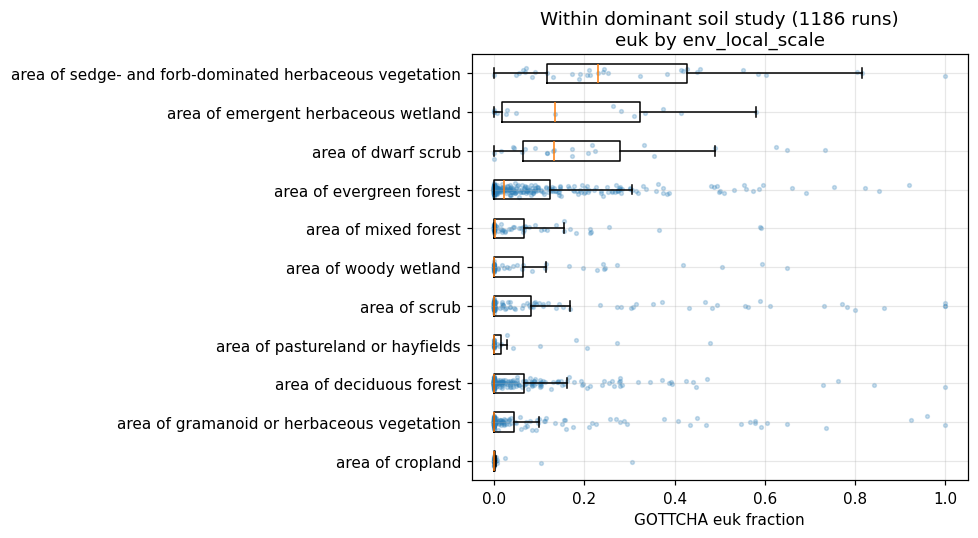

saved fig04


In [6]:
fig,ax=plt.subplots(figsize=(9,5))
order=tab.sort_values('median').index.tolist()
ax.boxplot([d.loc[d.env_local==g,'gott_euk_frac'] for g in order],vert=False,tick_labels=order,showfliers=False)
for i,g in enumerate(order):
    v=d.loc[d.env_local==g,'gott_euk_frac']; ax.scatter(v,np.random.normal(i+1,.07,size=len(v)),s=6,alpha=.25,color='#2c7fb8')
ax.set_xlabel('GOTTCHA euk fraction'); ax.set_title(f'Within dominant soil study ({len(d)} runs)\neuk by env_local_scale')
plt.tight_layout(); plt.savefig(FIG/'fig04_within_study_env.png'); plt.show(); print('saved fig04')

## NB04 takeaways (interpretation in REPORT)
- Tests whether euk fraction varies with local environment/geography **inside one study**, where batch is ~constant.
- If within-study Kruskal is significant and within-study R² > 0 (while cross-study R² < 0), the environment↔eukaryote
  association is **partly real, not purely batch** — but only demonstrable at fine scale within a soil study.
- If within-study effects vanish, euk fraction is idiosyncratic at the sample level given fixed protocol — strengthening
  the case that upstream (unmeasured) wet-lab/biomass factors dominate.